# ViT custom PTQ and codebook quantization from 2 to 8 bits

This notebook evaluates the trained ViT-B/16 CIFAR-10 classifier under full-model custom PTQ and scalar codebook weight quantization from 2 through 8 bits. Every accuracy uses all 10,000 CIFAR-10 test images. All 76 eligible kernels/embeddings/class-token tensors are quantized; rank-one parameters and activations remain FP32. No fake quantization or retraining is used.

The run is resumable and writes each completed row immediately. Compatible W4/W8 results from notebooks 22 and 19 are reused by default, leaving ten new full-dataset inference passes.

In [1]:
from pathlib import Path
import gc, json, platform, sys, time
import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists(): raise RuntimeError("Run from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from src.quantization.custom_quantization import (
    codebook_vectorize_model_n_bits, custom_ptq_n_bits,
    dequantize_tensor, reconstruct_codebook_tensor,
)
print(f"Python: {sys.version.split()[0]}; TensorFlow: {tf.__version__}; Keras: {keras.__version__}")
from src.models import VIT_BASE_PATCH16_224_IMAGENET_PRESET

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7; TensorFlow: 2.20.0; Keras: 3.14.1


## 1. Configuration

In [2]:
MODEL_PATH = PROJECT_ROOT / "artifacts" / "vit_cifar10_ptq" / "vit_cifar10_fp32.keras"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "vit_ptq_codebook_bit_sweep"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
RESULT_PATH = OUTPUT_DIR / "vit_ptq_codebook_2_to_8_bit.csv"
W4_W8_PATH = PROJECT_ROOT / "artifacts" / "vit_4bit_stratified_sensitivity" / "full_model_w4_vs_w8.csv"
W4_FP32_CACHE = PROJECT_ROOT / "artifacts" / "vit_4bit_stratified_sensitivity" / "cache" / "v1_w4_stratified_7_modules_full_cifar10" / "predictions" / "fp32_full_cifar10_test.npz"

BIT_WIDTHS = list(range(2, 9)); METHODS = ("ptq", "codebook")
NUM_TEST_IMAGES, BATCH_SIZE = 10_000, 32
PTQ_PER_CHANNEL = True
CODEBOOK_VECTOR_DIM, CODEBOOK_DTYPE = 1, np.float32
CODEBOOK_ITERATIONS, CODEBOOK_MAX_SAMPLES = 30, 100_000
RANDOM_SEED, FORCE_RECOMPUTE = 42, False
REUSE_EXISTING_W4_W8 = True

if not MODEL_PATH.exists(): raise FileNotFoundError(MODEL_PATH)
for directory in (OUTPUT_DIR,PREDICTION_DIR): directory.mkdir(parents=True,exist_ok=True)
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)
print("Expected first-run work: 10 new ViT inference passes after W4/W8 reuse.")

Expected first-run work: 10 new ViT inference passes after W4/W8 reuse.


## 2. Complete CIFAR-10 test split and trained checkpoint

In [3]:
(_, _),(test_images,test_labels)=keras.datasets.cifar10.load_data(); test_labels=test_labels.reshape(-1).astype(np.int32)
assert len(test_images)==len(test_labels)==NUM_TEST_IMAGES
image_converter=keras_hub.layers.ViTImageConverter(image_size=(224,224),scale=[1/127.5]*3,offset=[-1.0]*3,
    interpolation="bilinear",antialias=False,crop_to_aspect_ratio=True)
def preprocess_images(images): return image_converter(images)

model=keras.models.load_model(MODEL_PATH,compile=False); evaluation_model=keras.models.load_model(MODEL_PATH,compile=False)
baseline_weights=[weight.numpy() for weight in model.weights]; fp32_parameter_bytes=int(sum(value.nbytes for value in baseline_weights))
rows=[]
for weight_index,(weight,value) in enumerate(zip(model.weights,baseline_weights)):
    name=getattr(weight,"path",weight.name)
    selected=np.issubdtype(value.dtype,np.floating) and value.ndim>=2 and (name.endswith("/kernel") or name.endswith("/embeddings") or name.endswith("class_token"))
    if selected: rows.append({"weight_index":weight_index,"tensor":name,"parameter_count":int(value.size),"fp32_bytes":int(value.nbytes)})
coverage=pd.DataFrame(rows); assert len(coverage)==76,len(coverage)
candidate_names=coverage.tensor.tolist(); candidate_by_name=coverage.set_index("tensor").to_dict(orient="index")
print(f"Eligible tensors: {len(coverage)}; FP32 size: {fp32_parameter_bytes/1024**2:.2f} MiB")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Eligible tensors: 76; FP32 size: 327.33 MiB


## 3. Quantization, storage, and resumable inference helpers

In [4]:
def predict_labels(weights):
    evaluation_model.set_weights(weights); outputs=[]
    for start in range(0,NUM_TEST_IMAGES,BATCH_SIZE):
        logits=evaluation_model(preprocess_images(test_images[start:start+BATCH_SIZE]),training=False).numpy(); outputs.append(np.argmax(logits,axis=1))
    return np.concatenate(outputs).astype(np.int16)
def prediction_path(method,bits): return PREDICTION_DIR / f"{method}_w{bits}_predictions.npz"
def packed_ptq_bytes(tensor,bits): return int((tensor.values.size*bits+7)//8 + np.asarray(tensor.scale).nbytes)
def quantize_and_reconstruct(method,bits):
    names=set(candidate_names)
    if method=="ptq":
        result=custom_ptq_n_bits(model,num_bits=bits,per_channel=PTQ_PER_CHANNEL,included_tensor_names=names)["weights"]
        tensors=result.tensors; rebuild=dequantize_tensor; storage=lambda tensor:packed_ptq_bytes(tensor,bits)
    elif method=="codebook":
        result=codebook_vectorize_model_n_bits(model,num_bits=bits,vector_dim=CODEBOOK_VECTOR_DIM,mode="vector",included_tensor_names=names,
            codebook_dtype=CODEBOOK_DTYPE,max_kmeans_samples=CODEBOOK_MAX_SAMPLES,kmeans_iterations=CODEBOOK_ITERATIONS,seed=RANDOM_SEED)
        tensors=result.tensors; rebuild=reconstruct_codebook_tensor; storage=lambda tensor:int(tensor.estimated_compressed_size_bytes)
    else: raise ValueError(method)
    weights=baseline_weights.copy(); parameter_bytes=fp32_parameter_bytes; error2=signal=0.0
    for tensor in tensors:
        info=candidate_by_name[tensor.name]; original=baseline_weights[info["weight_index"]]; reconstructed=rebuild(tensor).astype(original.dtype)
        weights[info["weight_index"]]=reconstructed; parameter_bytes += storage(tensor)-info["fp32_bytes"]
        delta=original.astype(np.float64)-reconstructed.astype(np.float64); error2+=float(np.sum(delta**2)); signal+=float(np.sum(original.astype(np.float64)**2))
    if len(tensors)!=len(candidate_names): raise RuntimeError(f"Expected {len(candidate_names)} tensors, got {len(tensors)}")
    return weights,int(parameter_bytes),error2/signal
def load_saved_rows():
    if FORCE_RECOMPUTE or not RESULT_PATH.exists(): return []
    return pd.read_csv(RESULT_PATH).to_dict(orient="records")
def save_rows(rows): pd.DataFrame(rows).sort_values(["method","num_bits"]).to_csv(RESULT_PATH,index=False)

## 4. Reuse FP32 and compatible full-model W4/W8 evidence

In [5]:
local_fp32=PREDICTION_DIR / "fp32_predictions.npz"
if local_fp32.exists() and not FORCE_RECOMPUTE:
    with np.load(local_fp32) as cached: fp32_predictions=cached["predictions"]
elif W4_FP32_CACHE.exists() and not FORCE_RECOMPUTE:
    with np.load(W4_FP32_CACHE) as cached: fp32_predictions=cached["predictions"]
    np.savez_compressed(local_fp32,predictions=fp32_predictions)
else:
    fp32_predictions=predict_labels(baseline_weights); np.savez_compressed(local_fp32,predictions=fp32_predictions)
fp32_accuracy=float(np.mean(fp32_predictions==test_labels)); print(f"FP32 accuracy: {fp32_accuracy*100:.2f}%")

sweep_rows=load_saved_rows()
if REUSE_EXISTING_W4_W8 and not sweep_rows and W4_W8_PATH.exists() and not FORCE_RECOMPUTE:
    existing=pd.read_csv(W4_W8_PATH)
    for row in existing.itertuples(index=False):
        sweep_rows.append({"method":row.method_family,"num_bits":int(row.bit_width),"codebook_size":2**int(row.bit_width) if row.method_family=="codebook" else np.nan,
            "quantized_tensors":len(candidate_names),"correct_predictions":int(round(row.accuracy_percent/100*NUM_TEST_IMAGES)),"test_images":NUM_TEST_IMAGES,
            "accuracy_percent":float(row.accuracy_percent),"drop_from_fp32_pp":float(row.accuracy_degradation_pp),
            "prediction_disagreement_percent":float(row.prediction_disagreement_percent),"parameter_bytes":int(round(row.parameter_mib*1024**2)),
            "parameter_mib":float(row.parameter_mib),"compression_ratio_vs_fp32":float(row.compression_ratio_vs_fp32),
            "memory_reduction_percent":float(row.memory_reduction_percent),"weight_nmse":np.nan,"quantization_seconds":np.nan,"evaluation_seconds":np.nan,"source":"reused_w4_w8"})
    save_rows(sweep_rows); print("Seeded compatible W4/W8 rows from notebooks 19 and 22 artifacts.")
display(pd.DataFrame(sweep_rows).sort_values(["method","num_bits"]) if sweep_rows else pd.DataFrame())

FP32 accuracy: 95.73%
Seeded compatible W4/W8 rows from notebooks 19 and 22 artifacts.


,method,num_bits,codebook_size,quantized_tensors,correct_predictions,test_images,accuracy_percent,drop_from_fp32_pp,prediction_disagreement_percent,parameter_bytes,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,weight_nmse,quantization_seconds,evaluation_seconds,source
0,codebook,4,16.0,76,9520,10000,95.20,0.53,2.78,43335464,41.327919,7.920196,87.374050,NaN,NaN,NaN,reused_w4_w8
1,codebook,8,256.0,76,9573,10000,95.73,0.00,0.63,86250536,82.254921,3.979400,74.870584,NaN,NaN,NaN,reused_w4_w8
2,ptq,4,NaN,76,9523,10000,95.23,0.50,3.41,43570256,41.551834,7.877516,87.305643,NaN,NaN,NaN,reused_w4_w8
3,ptq,8,NaN,76,9579,10000,95.79,-0.06,0.16,86412368,82.409256,3.971947,74.823433,NaN,NaN,NaN,reused_w4_w8


## 5. Run every missing PTQ/codebook bit width

In [6]:
completed={(str(row["method"]),int(row["num_bits"])) for row in sweep_rows}
for bits in BIT_WIDTHS:
    for method in METHODS:
        key=(method,bits)
        if key in completed and not FORCE_RECOMPUTE:
            print(f"Skipping saved {method} W{bits}"); continue
        print(f"Running {method} W{bits}..."); start=time.perf_counter()
        weights,parameter_bytes,weight_nmse=quantize_and_reconstruct(method,bits); quantization_seconds=time.perf_counter()-start
        start=time.perf_counter(); predictions=predict_labels(weights); evaluation_seconds=time.perf_counter()-start
        np.savez_compressed(prediction_path(method,bits),predictions=predictions)
        accuracy=float(np.mean(predictions==test_labels)); row={"method":method,"num_bits":bits,"codebook_size":2**bits if method=="codebook" else np.nan,
            "quantized_tensors":len(candidate_names),"correct_predictions":int(np.sum(predictions==test_labels)),"test_images":NUM_TEST_IMAGES,
            "accuracy_percent":accuracy*100,"drop_from_fp32_pp":(fp32_accuracy-accuracy)*100,"prediction_disagreement_percent":float(np.mean(predictions!=fp32_predictions)*100),
            "parameter_bytes":parameter_bytes,"parameter_mib":parameter_bytes/1024**2,"compression_ratio_vs_fp32":fp32_parameter_bytes/parameter_bytes,
            "memory_reduction_percent":(1-parameter_bytes/fp32_parameter_bytes)*100,"weight_nmse":weight_nmse,
            "quantization_seconds":quantization_seconds,"evaluation_seconds":evaluation_seconds,"source":"computed"}
        sweep_rows=[old for old in sweep_rows if (str(old["method"]),int(old["num_bits"]))!=key]+[row]; save_rows(sweep_rows); completed.add(key)
        print(f"  accuracy={accuracy*100:.2f}% compression={row['compression_ratio_vs_fp32']:.2f}x; inference={evaluation_seconds/60:.1f} min")
        del weights,predictions; gc.collect()
sweep=pd.DataFrame(sweep_rows).sort_values(["method","num_bits"]); assert len(sweep)==14; display(sweep)

Running ptq W2...
  accuracy=13.00% compression=15.50x; inference=22.0 min
Running codebook W2...
  accuracy=20.84% compression=15.66x; inference=23.8 min
Running ptq W3...
  accuracy=32.22% compression=10.45x; inference=24.8 min
Running codebook W3...
  accuracy=89.77% compression=10.52x; inference=24.5 min
Skipping saved ptq W4
Skipping saved codebook W4
Running ptq W5...
  accuracy=95.83% compression=6.32x; inference=25.7 min
Running codebook W5...
  accuracy=95.64% compression=6.35x; inference=33.9 min
Running ptq W6...
  accuracy=95.70% compression=5.28x; inference=26.8 min
Running codebook W6...
  accuracy=95.76% compression=5.30x; inference=23.7 min
Running ptq W7...
  accuracy=95.75% compression=4.53x; inference=24.7 min
Running codebook W7...
  accuracy=95.68% compression=4.55x; inference=25.0 min
Skipping saved ptq W8
Skipping saved codebook W8


,method,num_bits,codebook_size,quantized_tensors,correct_predictions,test_images,accuracy_percent,drop_from_fp32_pp,prediction_disagreement_percent,parameter_bytes,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,weight_nmse,quantization_seconds,evaluation_seconds,source
5,codebook,2,4.0,76,2084,10000,20.84,74.89,78.98,21910760,20.895729,15.664696,93.616218,0.137422,21.847120,1425.626126,computed
7,codebook,3,8.0,76,8977,10000,89.77,5.96,9.88,32622504,31.111244,10.521123,90.495311,0.044774,25.481574,1468.131496,computed
0,codebook,4,16.0,76,9520,10000,95.20,0.53,2.78,43335464,41.327919,7.920196,87.374050,NaN,NaN,NaN,reused_w4_w8
9,codebook,5,32.0,76,9564,10000,95.64,0.09,1.49,54050856,51.546913,6.350045,84.252081,0.004012,39.240081,2033.520838,computed
11,codebook,6,64.0,76,9576,10000,95.76,-0.03,0.82,64771112,61.770546,5.299050,81.128694,0.001312,54.678344,1422.607338,computed
13,codebook,7,128.0,76,9568,10000,95.68,0.05,0.58,75501096,72.003456,4.545966,78.002473,0.000607,91.833309,1502.901793,computed
1,codebook,8,256.0,76,9573,10000,95.73,0.00,0.63,86250536,82.254921,3.979400,74.870584,NaN,NaN,NaN,reused_w4_w8
4,ptq,2,NaN,76,1300,10000,13.00,82.73,86.90,22149200,21.123123,15.496062,93.546748,0.823806,0.467795,1321.328210,computed
6,ptq,3,NaN,76,3222,10000,32.22,63.51,67.55,32859728,31.337479,10.445168,90.426195,0.181719,0.458006,1485.577844,computed
2,ptq,4,NaN,76,9523,10000,95.23,0.50,3.41,43570256,41.551834,7.877516,87.305643,NaN,NaN,NaN,reused_w4_w8


## 6. Accuracy–compression tables and figures

method,codebook,ptq
num_bits,,
2,20.84,13.00
3,89.77,32.22
4,95.20,95.23
5,95.64,95.83
6,95.76,95.70
7,95.68,95.75
8,95.73,95.79


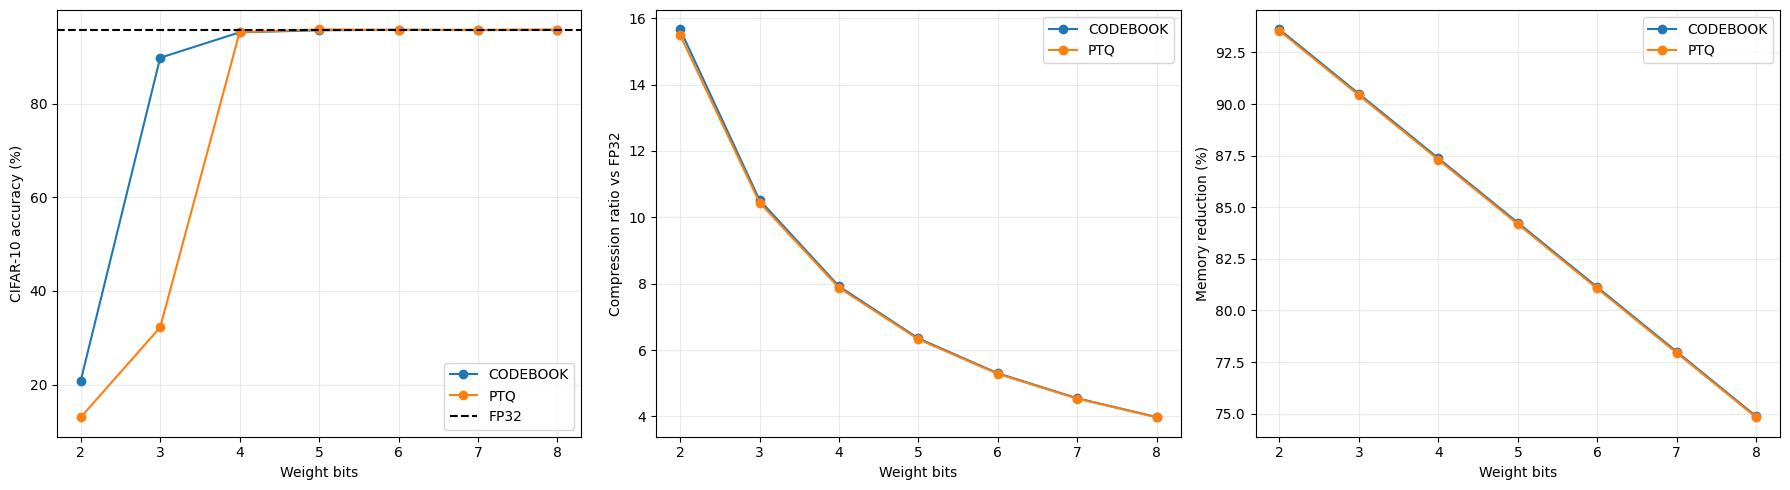

Saved under /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/vit_ptq_codebook_bit_sweep


In [7]:
display(sweep.pivot(index="num_bits",columns="method",values="accuracy_percent"))
fig,axes=plt.subplots(1,3,figsize=(18,5))
for method,group in sweep.groupby("method"):
    group=group.sort_values("num_bits"); axes[0].plot(group.num_bits,group.accuracy_percent,"o-",label=method.upper())
    axes[1].plot(group.num_bits,group.compression_ratio_vs_fp32,"o-",label=method.upper())
    axes[2].plot(group.num_bits,group.memory_reduction_percent,"o-",label=method.upper())
axes[0].axhline(fp32_accuracy*100,color="black",linestyle="--",label="FP32")
axes[0].set_ylabel("CIFAR-10 accuracy (%)"); axes[1].set_ylabel("Compression ratio vs FP32"); axes[2].set_ylabel("Memory reduction (%)")
for axis in axes: axis.set_xlabel("Weight bits"); axis.set_xticks(BIT_WIDTHS); axis.grid(alpha=.25); axis.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "vit_ptq_codebook_2_to_8_bit.png",dpi=180,bbox_inches="tight"); plt.show()
coverage.to_csv(OUTPUT_DIR / "tensor_coverage.csv",index=False)
metadata={"model":str(MODEL_PATH),"dataset":"CIFAR-10 complete test split","test_images":NUM_TEST_IMAGES,"bits":BIT_WIDTHS,
    "methods":METHODS,"eligible_tensors":len(candidate_names),"activations_quantized":False,"fake_quantization":False,
    "storage":"theoretical packed assignments plus scales/codebooks and skipped FP32 tensors","fp32_accuracy_percent":fp32_accuracy*100,
    "tensorflow":tf.__version__,"keras":keras.__version__,"python":sys.version,"hardware":platform.platform()}
(OUTPUT_DIR / "results.json").write_text(json.dumps(metadata,indent=2,default=str)); print(f"Saved under {OUTPUT_DIR}")

## Runtime and interpretation

- W4/W8 rows are reused, so the first run normally performs ten new full-test evaluations.
- On the current laptop, each ViT evaluation has taken roughly 25–35 minutes; allow approximately 5–7 hours plus codebook construction.
- Stop/restart is safe after a printed completed row because the CSV and predictions are saved immediately.
- Storage is theoretical packed representation size. Accuracy uses reconstructed weights and FP32 activations, not native packed low-bit kernels.